In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Read in the processed dataset
file_path = '../data/processed/processed_data_pre_model.csv'
df = pd.read_csv(file_path, parse_dates=['month_date_yyyymm'], date_format={'month_date_yyyymm': '%Y-%m-%d'})

C:\Users\sbout\AppData\Local\Temp\ipykernel_42416\2593799478.py:3: DtypeWarning: Columns (46,48,75,88) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, parse_dates=['month_date_yyyymm'], date_format={'month_date_yyyymm': '%Y-%m-%d'})


In [3]:
# Remove columns that are redundant
cols_to_remove = ['median_listing_price_vs_us', 'average_listing_price', 'median_listing_price_per_square_foot', 
'pending_listing_count', 'U.S. 15 year FRM', 'highest_category', 'median_dom_vs_us', 
'median_days_on_market_yy_y', 'median_days_on_market_mm_y', 'median_listing_price_yy_y', 
'median_listing_price_mm_y', 'median_listing_price_y', 'active_listing_count', 'median_listing_price_per_square_foot_mm', 
'average_listing_price_yy', 'average_listing_price_mm', '15 year fees & points', 'page_view_count_per_property_vs_us', 
'median_dom_mm_day', 'date_y', 'date_x', 'quality_flag_y', 'median_dom_yy_day', 'median_dom_mm_day', 'quality_flag_x', 
'pending_listing_count', 'pending_listing_count_mm', 'pending_listing_count_yy'
]

df_reduced = df.drop(columns=cols_to_remove)
print(f"Original feature count: {df.shape[1]}")
print(f"Reduced feature count: {df_reduced.shape[1]}")
print(f"Removed features: {cols_to_remove}")

Original feature count: 90
Reduced feature count: 64
Removed features: ['median_listing_price_vs_us', 'average_listing_price', 'median_listing_price_per_square_foot', 'pending_listing_count', 'U.S. 15 year FRM', 'highest_category', 'median_dom_vs_us', 'median_days_on_market_yy_y', 'median_days_on_market_mm_y', 'median_listing_price_yy_y', 'median_listing_price_mm_y', 'median_listing_price_y', 'active_listing_count', 'median_listing_price_per_square_foot_mm', 'average_listing_price_yy', 'average_listing_price_mm', '15 year fees & points', 'page_view_count_per_property_vs_us', 'median_dom_mm_day', 'date_y', 'date_x', 'quality_flag_y', 'median_dom_yy_day', 'median_dom_mm_day', 'quality_flag_x', 'pending_listing_count', 'pending_listing_count_mm', 'pending_listing_count_yy']


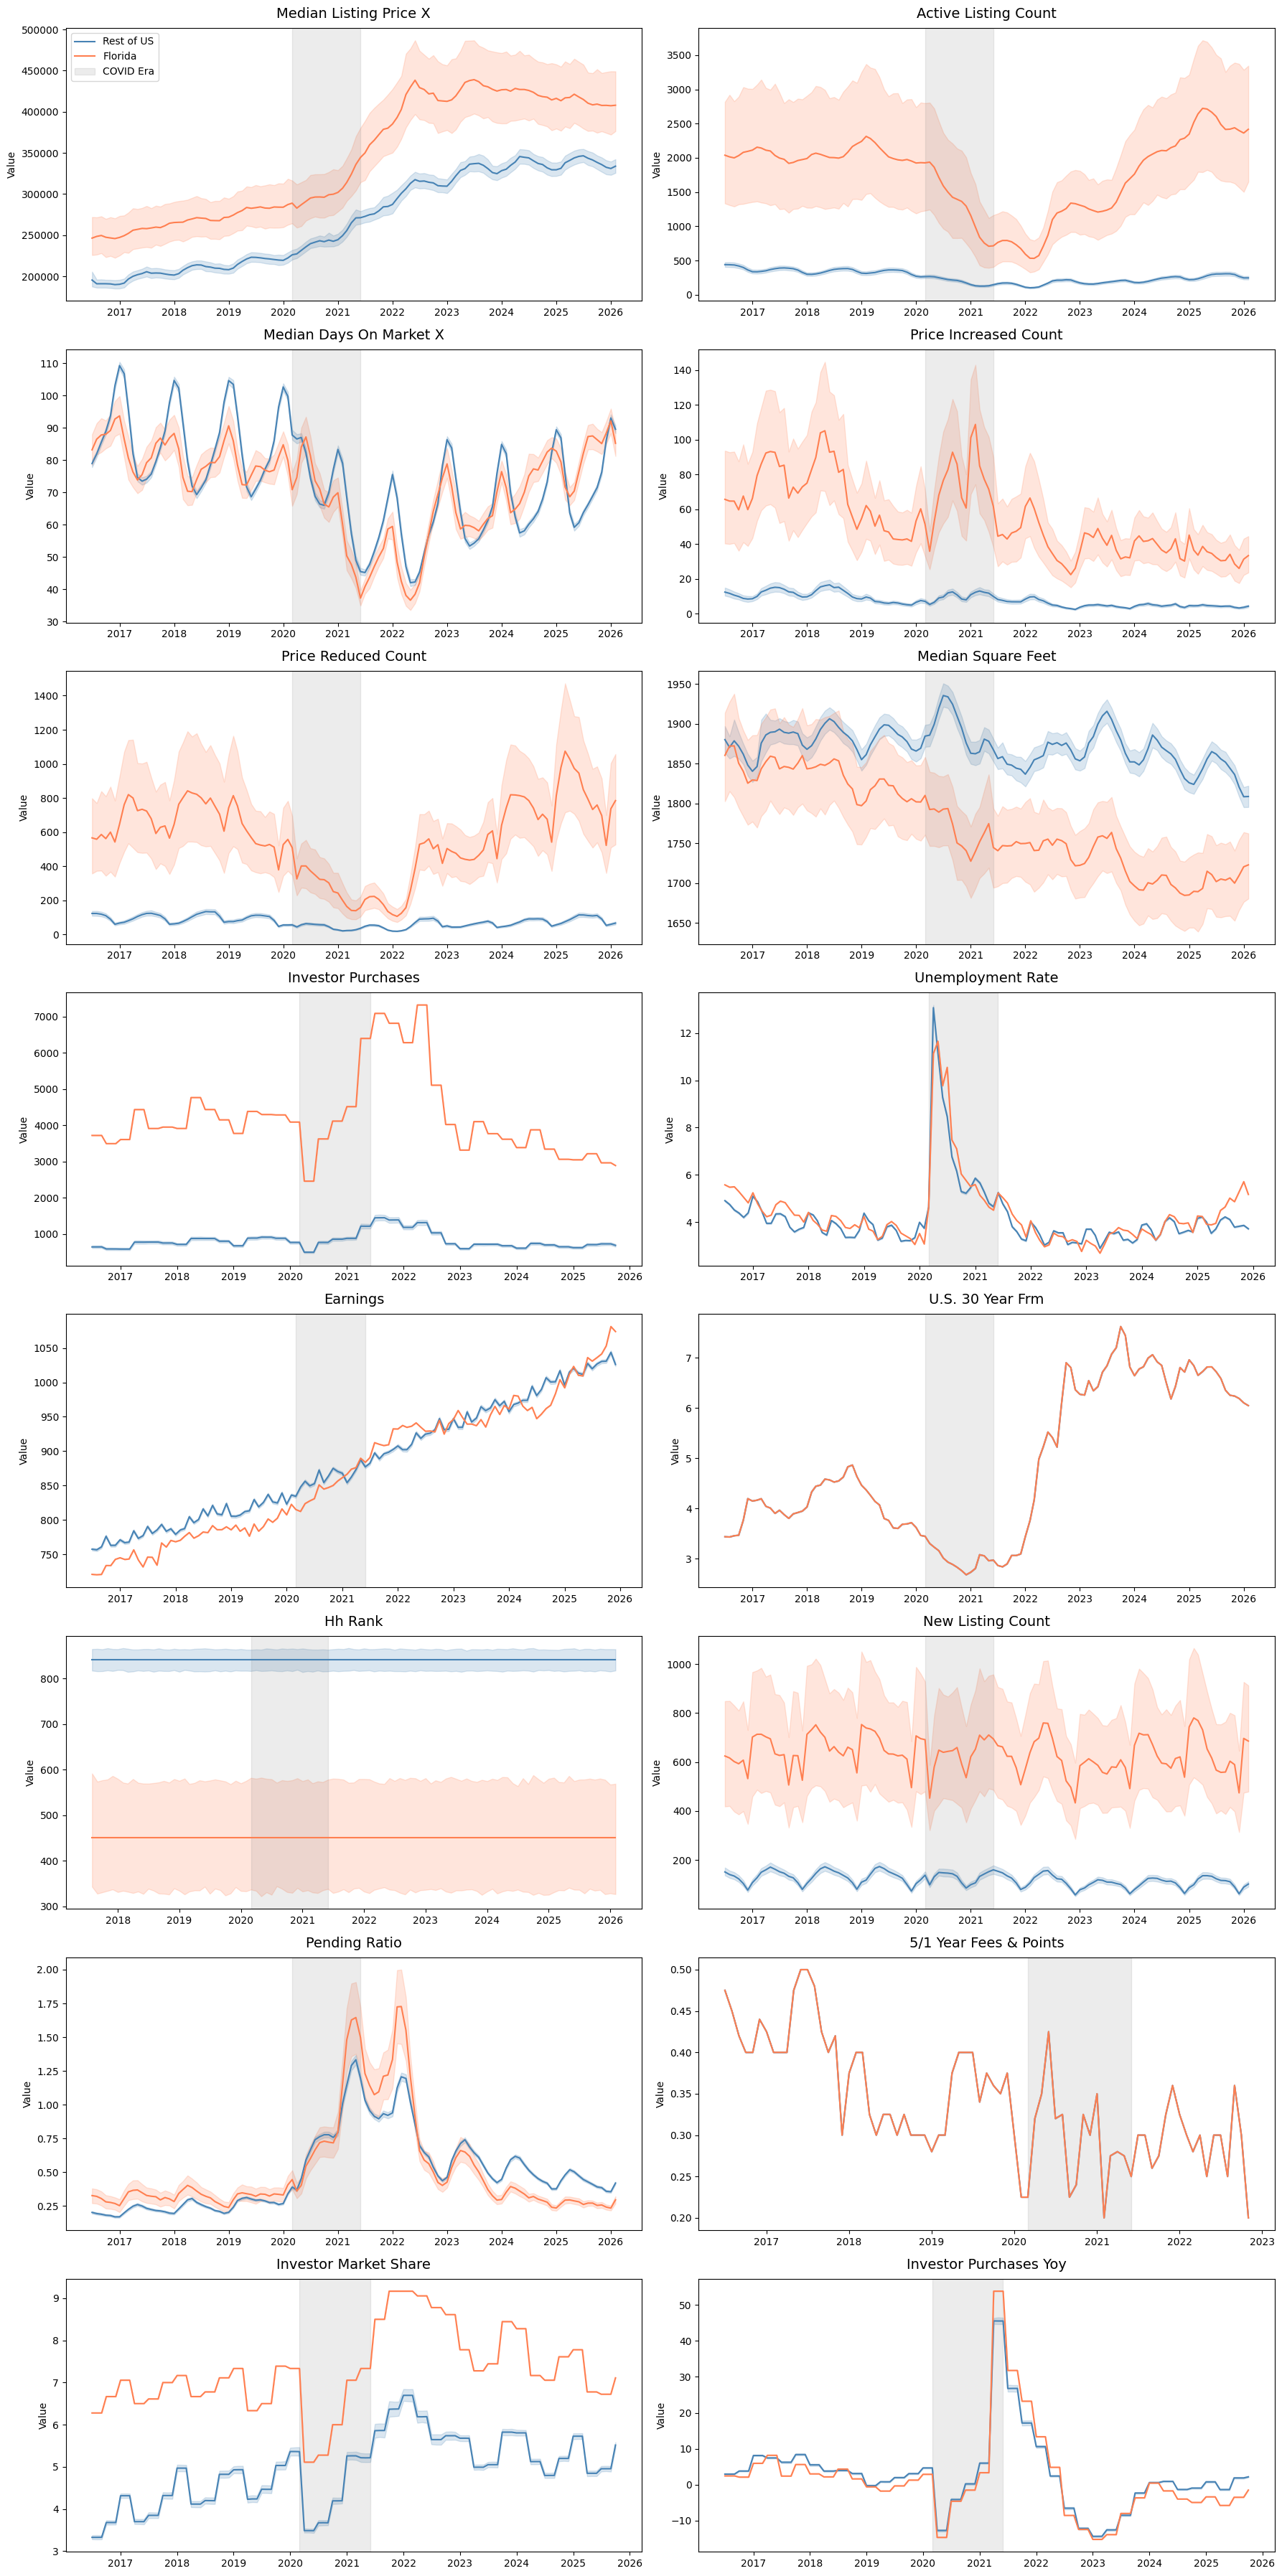

In [4]:
# Convert time column into true Datetime objects
df['date'] = pd.to_datetime(df['month_date_yyyymm'].astype(str), format='%Y-%m-%d')

# Create a 'Region' column to split the dataset
df['Region'] = 'Rest of US'

# Change the Region name to Florida for all state = fl
df.loc[df['state'] == 'fl', 'Region'] = 'Florida' 

columns_to_plot = [
    'median_listing_price_x', 'active_listing_count', 'median_days_on_market_x', 
    'price_increased_count', 'price_reduced_count', 'median_square_feet',  
    'Investor Purchases', 'Unemployment_Rate', 'Earnings', 'U.S. 30 year FRM',
    'hh_rank', 'new_listing_count', 'pending_ratio', '5/1 year fees & points',
    'Investor Market Share', 'Investor Purchases YoY'
]

# Set up plot
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(18, 36))
axes = axes.flatten()

# Define COVID era shading boundaries (Year-Month-Day)
covid_start = pd.to_datetime('2020-03-01')
covid_end = pd.to_datetime('2021-05-31')

# Plot

for i, col in enumerate(columns_to_plot):
    if col in df.columns:
        # Plot both regions on the same axis. Seaborn will automatically color-code them.
        sns.lineplot(
            data=df, 
            x='date', 
            y=col, 
            hue='Region', 
            ax=axes[i], 
            palette={'Florida': 'coral', 'Rest of US': 'steelblue'},
            # errorbar=None  # Uncomment this line if the confidence interval shadows are too messy
        )
        
        # Clean up the titles 
        clean_title = col.replace('_', ' ').title()
        axes[i].set_title(clean_title, fontsize=14, pad=10)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Value')
        
        # Add the light shading for the COVID era. alpha=0.15 makes it very faint.
        axes[i].axvspan(covid_start, covid_end, color='gray', alpha=0.15)
        
        # Only keep the legend on the very first plot
        if i == 0:
            # add a dummy patch to the legend to explain what the gray box is
            import matplotlib.patches as mpatches
            covid_patch = mpatches.Patch(color='gray', alpha=0.15, label='COVID Era')
            handles, labels = axes[i].get_legend_handles_labels()
            axes[i].legend(handles=handles + [covid_patch], loc='best')
        else:
            # Remove redundant legends on the other 15 plots
            axes[i].get_legend().remove()
            
    else:
        axes[i].set_visible(False)
        # Note: If a chart goes missing, check if it's 'Unemployment_rate' vs 'Unemployment_Rate'!
        print(f"Warning: Column '{col}' not found. Check capitalization!")

# Adjust the layout to keep it looking clean
plt.tight_layout()
plt.show()
